In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import superstats as sup
import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


In [3]:
NUM_STEPS = 100

In [39]:
test_prior = sup.JointPrior(
    a = sup.transition.Linear(),
    b = sup.transition.Polynomial(
        betas=sup.Prior("normal", scale=5)
    ),
    c = sup.transition.Exponential(),
    d = sup.transition.Logarithmic(beta=sup.Prior("normal", scale=5))
)

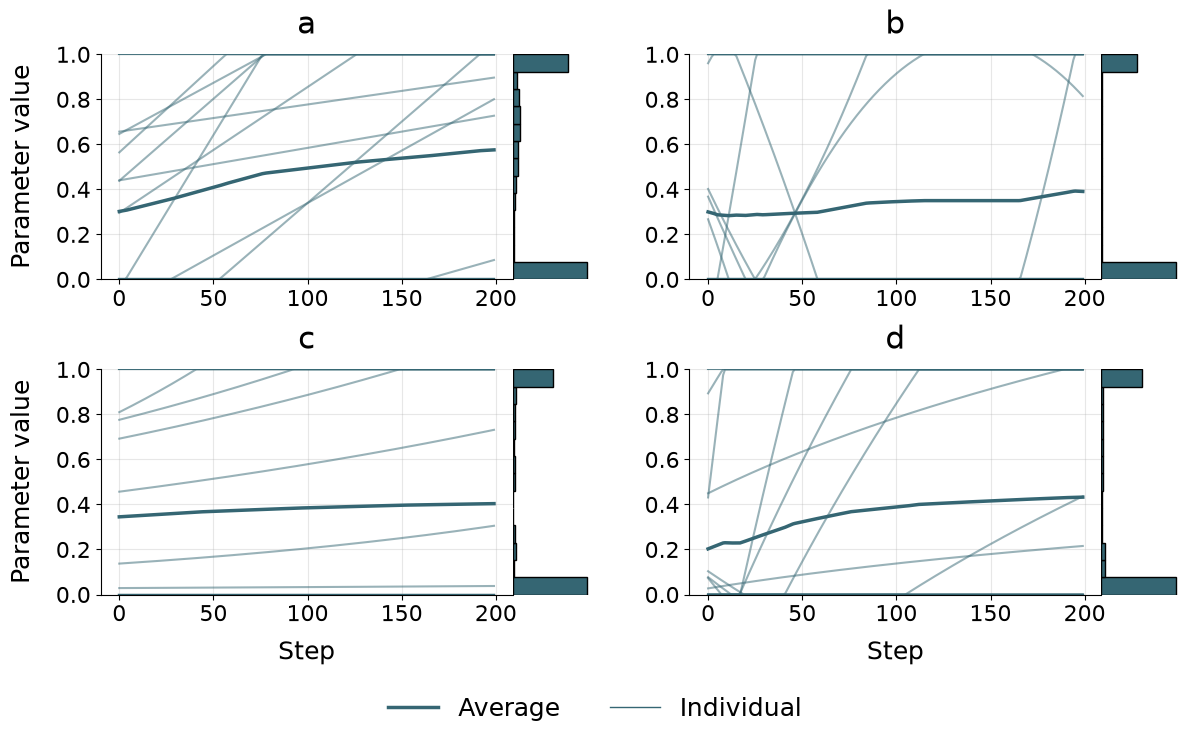

In [40]:
fig = test_prior.plot_time_varying_prior(
    # num_cols=1
)

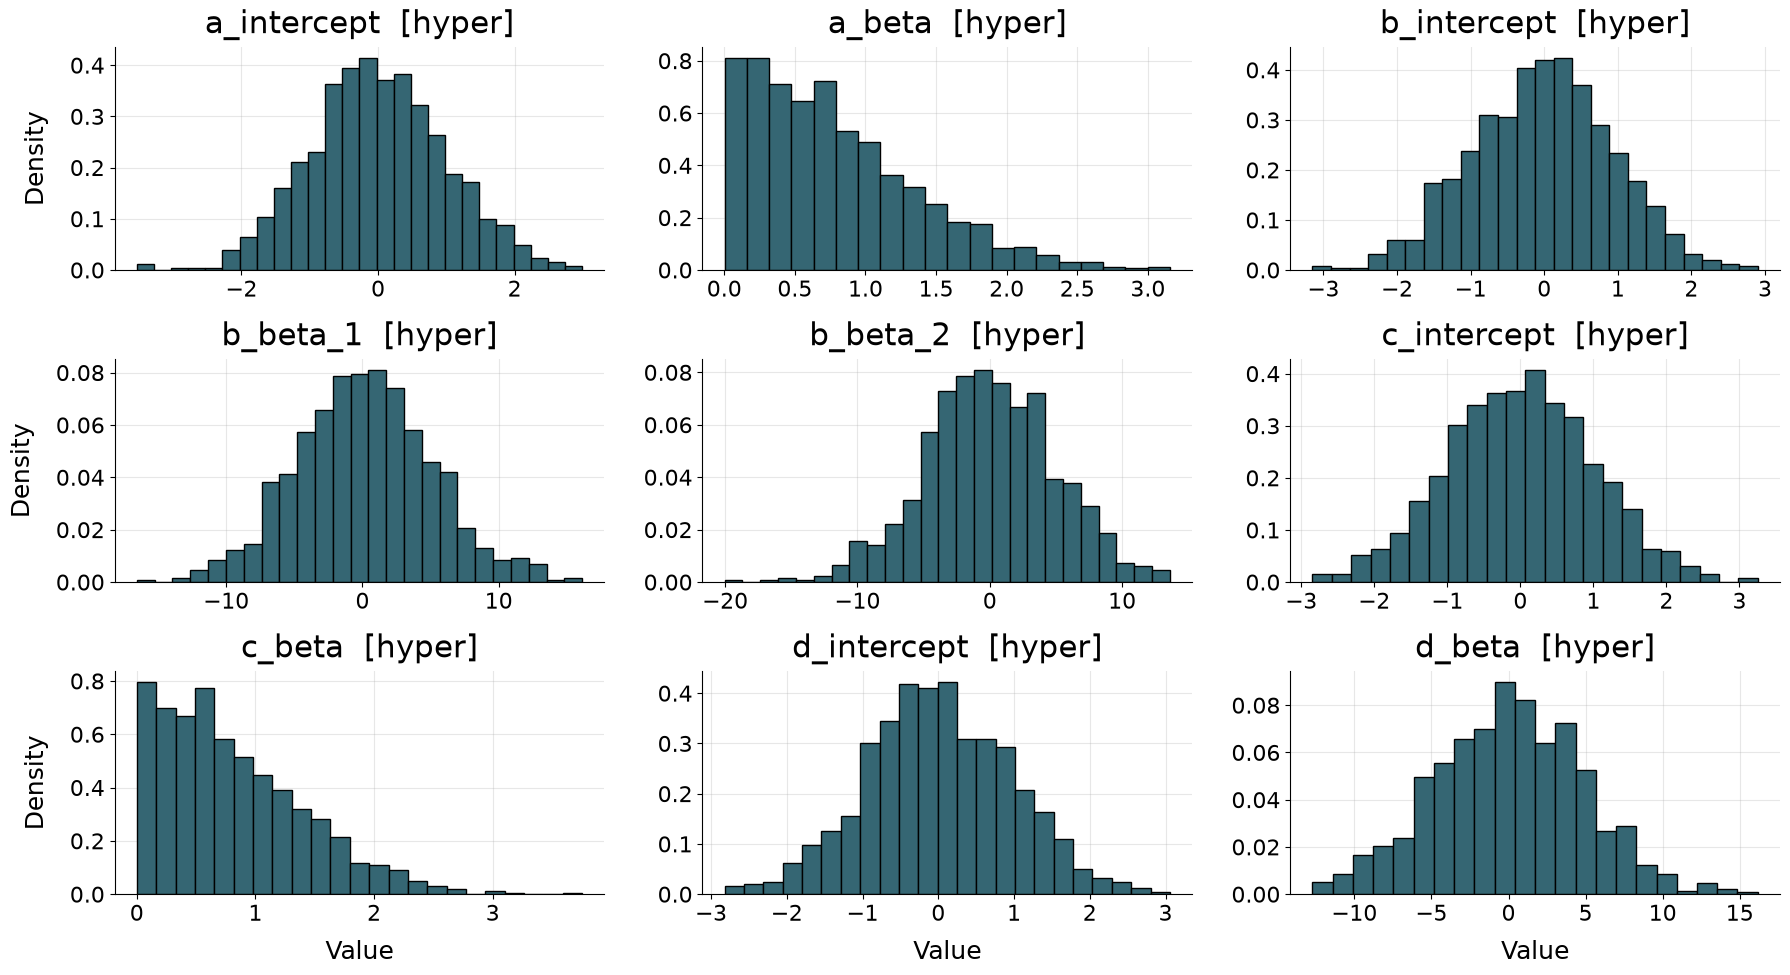

In [41]:
fig = test_prior.plot_time_invariant_prior()

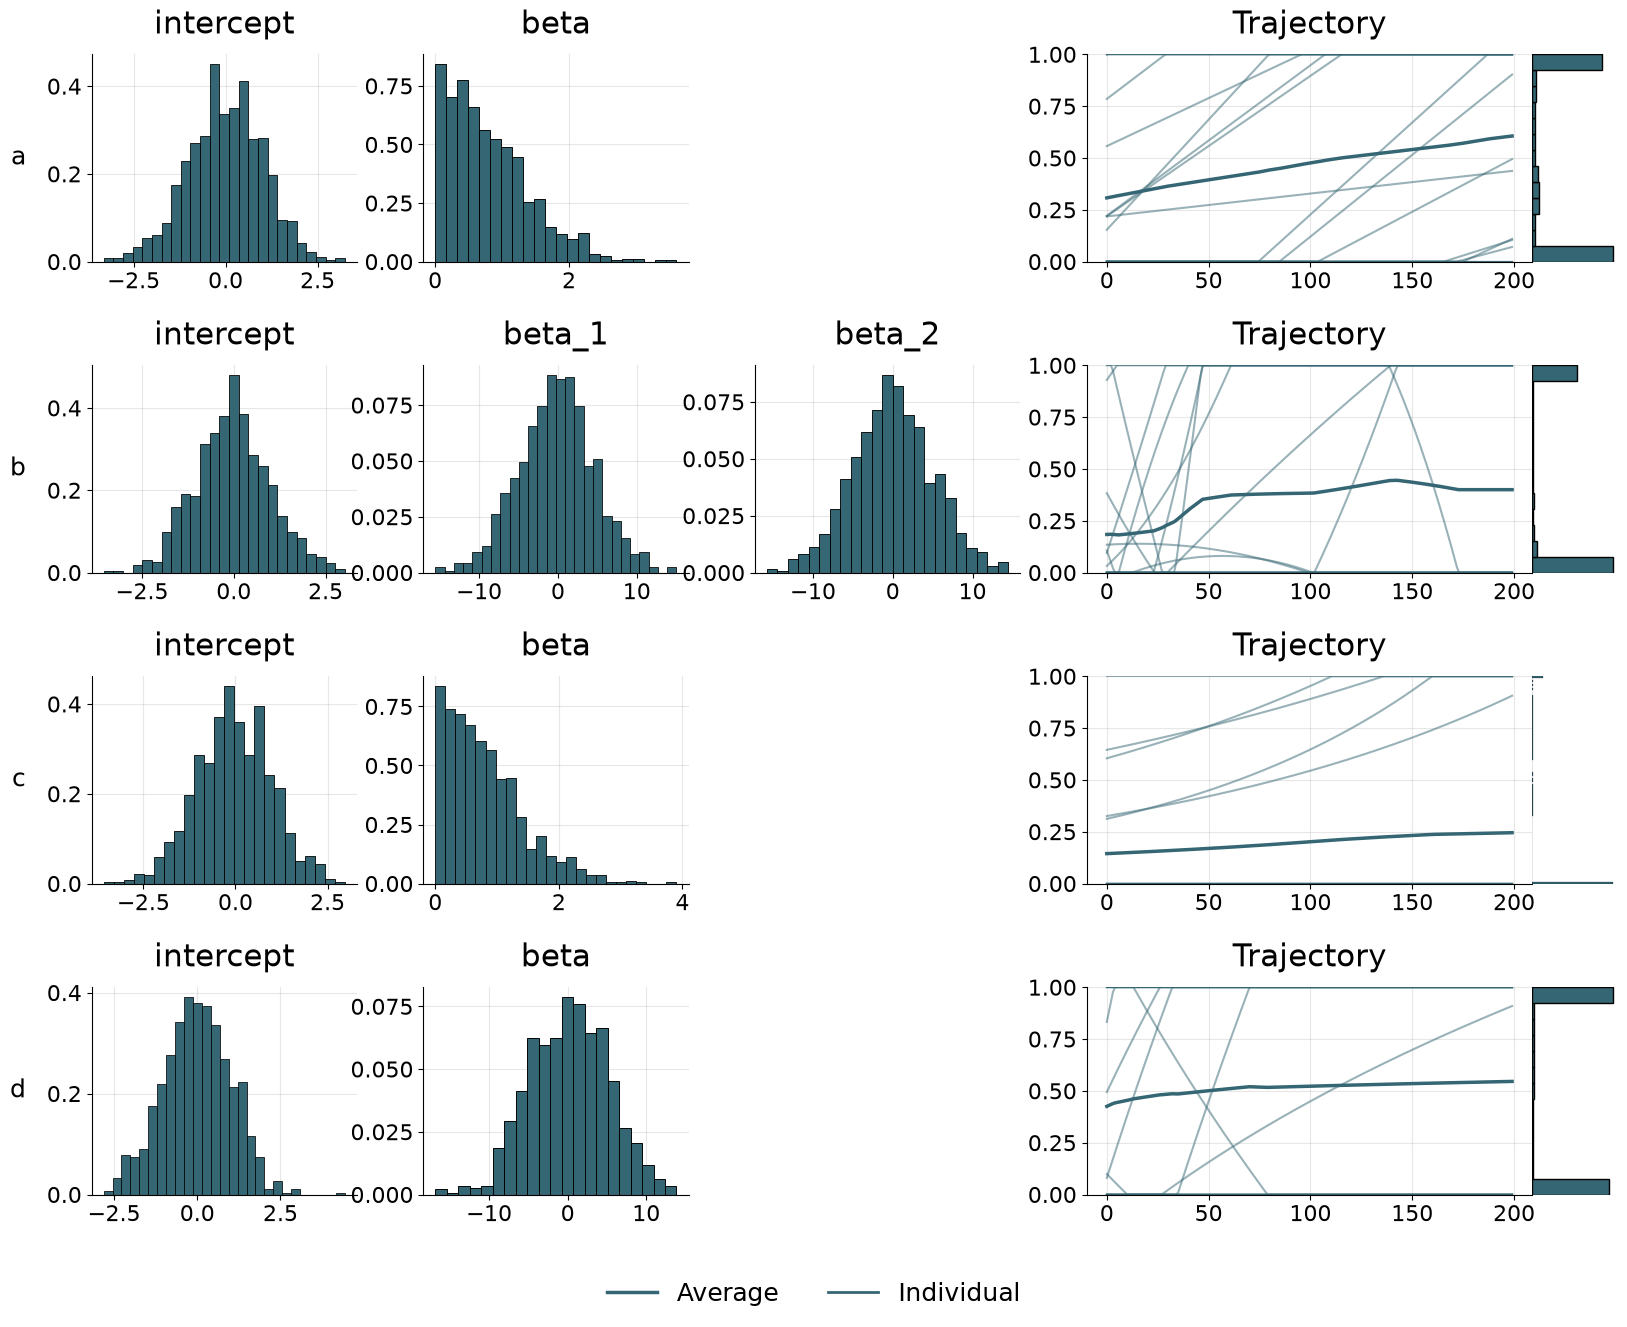

In [42]:
fig = test_prior.plot_joint_prior()

In [4]:
prior = sup.JointPrior(
    v = sup.transition.RandomWalk(bounds=(0.0, 6.0)),
    a = sup.transition.RandomWalk(bounds=(0.2, 4.0)),
    tau = sup.transition.RandomWalk(bounds=(0.0, 2.0)),
    bias = 0.5
)

In [5]:
contamination = sup.simulation.RandomChoiceContamination(
    p_contaminated=sup.transition.RandomWalk(
        bounds=(0.0, 1.0),
        sigma=sup.Prior("halfnormal", scale=0.05),
        delta=0.0,
    ),
    infer=True,
)

In [7]:
model = sup.Model(
    prior=prior,
    simulator=sup.simulation.sample_ddm,
    missing=None,
    contamination=contamination
)

In [12]:
sim_data = model.sample(32, NUM_STEPS)
sim_data.keys()
model.hyper_keys

['v_sigma', 'a_sigma', 'tau_sigma', 'p_contaminated_sigma']

In [ ]:
fig = model.plot_push_forward(
    batch_size=10,
    kind="dist",
    dist_type="hist",
    # aggregation=np.mean,
)

In [ ]:
workflow = sup.Workflow(
    model=model,
    embedding_network=sup.networks.RecurrentNet(),
    inference_network="coupling"
)

In [ ]:
train_data = model.sample(
    batch_size=20,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)
val_data = model.sample(
    batch_size=10,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=val_data,
    epochs=2,
    batch_size=32
)

In [ ]:
fig = workflow.plot_history(workflow.history)

In [ ]:
samples = workflow.sample(
    data=val_data,
    num_samples=100,
    batch_size=2
)

In [ ]:
fig = workflow.verify_time_varying(
    targets=val_data,
    estimates=samples
)

In [ ]:
fig = workflow.recovery_at_steps(
    targets=val_data,
    estimates=samples,
    time_steps=[40, 66]
)

In [ ]:
fig = workflow.calibration_at_steps(
    targets=val_data,
    estimates=samples,
    time_steps=[40, 66]
)

In [ ]:
fig = workflow.z_score_contraction_at_steps(
    targets=val_data,
    estimates=samples,
    time_steps=[40, 66]
)

In [ ]:
fig = workflow.verify_time_invariant(
    targets=val_data,
    estimates=samples
)

In [ ]:
resim_data = workflow.resimulate(
    samples,
    num_sims=10
)

In [ ]:
fig = sup.diagnostics.plot_posterior_resimulation(
    prediction=resim_data,
    empirical=val_data,
    # kind="dist",
    # aggregation=np.mean,
    smoothing="ema",
    aggregate_strategy="full_uncertainty",
    num_bins=40,
    data_idx=[1, 2],
    # dist_type="kde"
)

In [ ]:
fig = workflow.plot_time_varying_posterior(
    estimates=samples,
    targets=val_data,
    # aggregation=np.median,
    data_idx=[1, 4],
    # num_cols=1
)

In [ ]:
fig = workflow.plot_time_invariant_posterior(
    estimates=samples,
    targets=val_data,
    # aggregation=np.median,
    data_idx=[1, 2],
    # num_cols=3
)